# Plot Log Error Decay With Fixed $s_0, q_0$

This notebook fixes `s0` and `q0`, then scans over `r` to compare deterministic bias, sampled error, and sampled fluctuation for log-NCC.

In [ ]:
import math

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

from NCC_log import build_static_data, build_tilde_V

%config InlineBackend.figure_format = 'retina'
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams.update({'font.size': 16})
plt.rcParams['text.usetex'] = True

N = 4
J = 1.0
h = 1.0
T = 0.6
EPSILON_REF = 0.01
S0 = 6
Q0 = 8
TRIALS = 200
REPEATS = 3
BASE_SEED = 7
R_VALUES = [2, 4, 8, 12, 16, 24, 32, 48, 64]

static = build_static_data(N, EPSILON_REF, j=J, h=h, K=1, q0=Q0, s0=S0)
print({'N': N, 'T': T, 's0': static['s0'], 'q0': static['q0'], 'trials': TRIALS, 'repeats': REPEATS})


def sample_Pauli_then_compensate_exp(rng, identity, F_terms, order, eta_pair_sum, pair_scale, raw_total, atol=1e-10):
    F_term = F_terms[order]
    probs = np.abs(F_term['coeffs']) / F_term['l1_norm']
    idx = int(rng.choice(len(F_term['terms']), p=probs))
    coeff = F_term['coeffs'][idx]
    pauli = F_term['terms'][idx]
    if F_term['kind'] == 'pair':
        phase = coeff / (1j * abs(coeff))
        W_mat = phase * pauli
        hermitian_err = np.linalg.norm(W_mat - W_mat.conj().T, ord='fro')
        if hermitian_err > atol:
            raise ValueError(f'sampled W is not Hermitian (herm_err={hermitian_err:.3e})')
        # apply exp(i theta W), you must multiply total 1-norm raw_total.
        return raw_total * ((identity + 1j * eta_pair_sum * W_mat) / pair_scale)
    # apply W like (1+i)X, you must multiply total 1-norm raw_total.
    return raw_total * (coeff / abs(coeff) * pauli)


def estimate_sample_metrics(static, T, r, trials, seed):
    evolution_data = build_tilde_V(static, T, r)
    identity = static['identity']
    F_terms = static['F_terms']
    s_orders = static['s_orders']
    raw_weights = evolution_data['raw_weights']
    raw_total = float(sum(raw_weights.values()))
    p_order = np.array([raw_weights[s] / raw_total for s in s_orders], dtype=float)

    rng = np.random.default_rng(seed)
    U_total_average = np.zeros_like(identity)
    for _ in range(trials):
        evo = identity.copy()
        for _ in range(r):
            order = int(rng.choice(s_orders, p=p_order))
            evo = sample_Pauli_then_compensate_exp(
                rng,
                identity,
                F_terms,
                order,
                evolution_data['eta_pair_sum'],
                evolution_data['pair_scale'],
                raw_total,
            ) @ evolution_data['S1'] @ evo
        U_total_average += evo
    U_total_average /= trials

    return {
        'sample_error': float(np.linalg.norm(U_total_average - evolution_data['U_exact'], 2)),
        'sample_fluctuation': float(np.linalg.norm(U_total_average - evolution_data['deterministic'], 2)),
        'expectation_bias': float(evolution_data['deterministic_bias']),
        'eta_pair_sum': float(evolution_data['eta_pair_sum']),
        'raw_total': raw_total,
        'validation_error': float(evolution_data['validation_error']),
    }


{'N': 4, 'T': 0.6, 's0': 6, 'q0': 8, 'trials': 200, 'repeats': 3}


100%|██████████| 9/9 [00:03<00:00,  2.98it/s]


{'r': 2, 'expectation_bias': 0.7628539768511495, 'sample_error_mean': 45.05519267735224, 'sample_error_low': 43.535389173861454, 'sample_error_high': 46.57499618084302, 'sample_fluctuation_mean': 45.03821887335468, 'sample_fluctuation_low': 43.49401449951801, 'sample_fluctuation_high': 46.58242324719135, 'eta_pair_sum': 7.631999999999999, 'raw_total': 19.23146202817044, 'validation_error': 8.583909751539516e-16}
{'r': 4, 'expectation_bias': 0.011010991411737427, 'sample_error_mean': 2.468898782220164, 'sample_error_low': 2.3169157751047966, 'sample_error_high': 2.6208817893355314, 'sample_fluctuation_mean': 2.4693748633020616, 'sample_fluctuation_low': 2.318202232776513, 'sample_fluctuation_high': 2.62054749382761, 'eta_pair_sum': 1.3139999999999998, 'raw_total': 2.136630545621304, 'validation_error': 7.90961598907956e-16}
{'r': 8, 'expectation_bias': 0.00014700062262615535, 'sample_error_mean': 0.14464048968394985, 'sample_error_low': 0.12916971021042545, 'sample_error_high': 0.160111

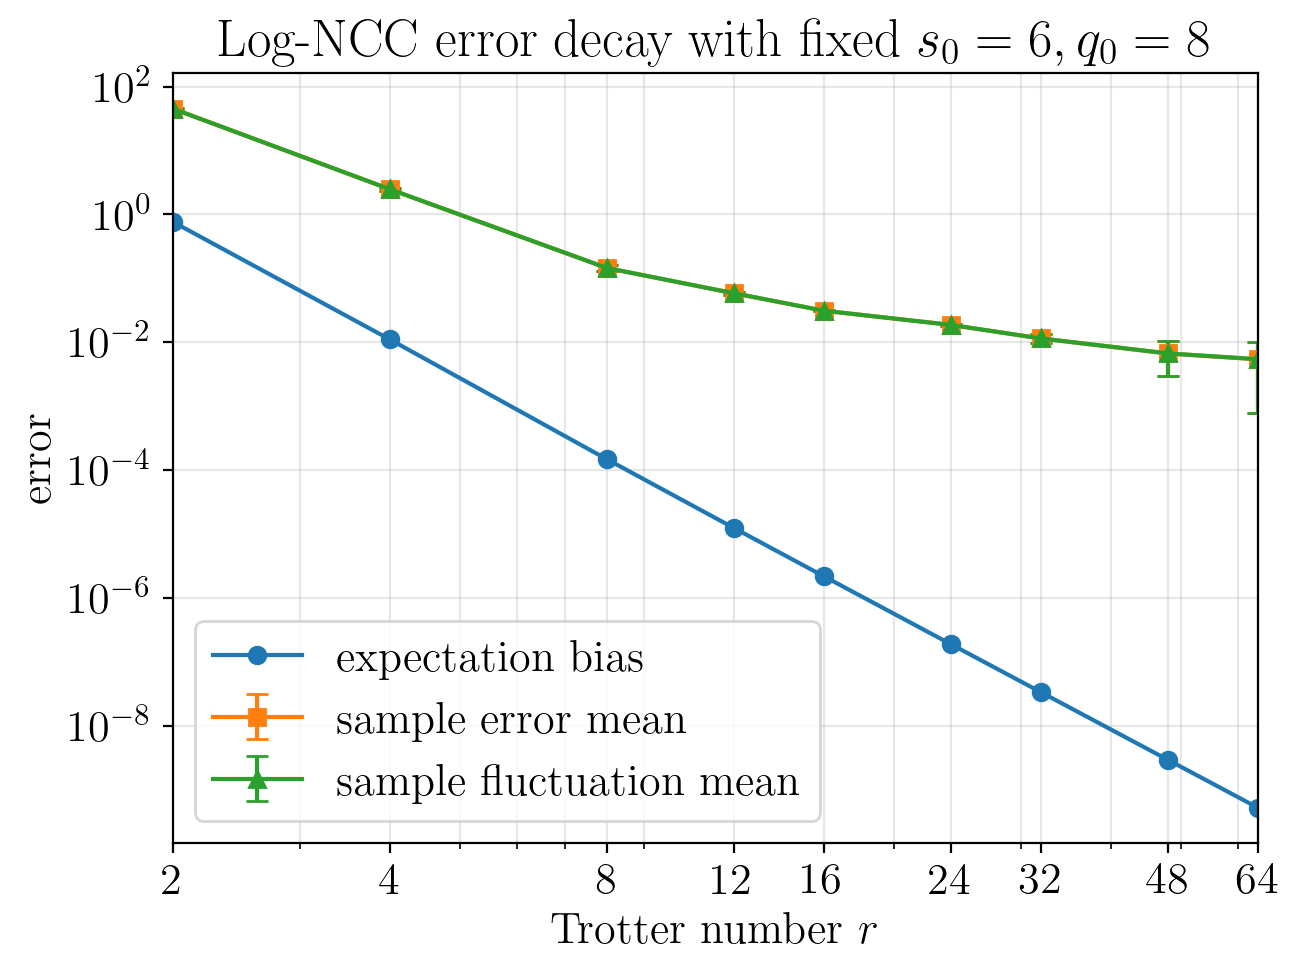

In [4]:
rows = []
for r in tqdm(R_VALUES):
    sampled_errors = []
    sampled_fluctuations = []
    metrics0 = None
    for repeat in range(REPEATS):
        metrics = estimate_sample_metrics(static, T, r, TRIALS, BASE_SEED + 100_003 * repeat)
        sampled_errors.append(metrics['sample_error'])
        sampled_fluctuations.append(metrics['sample_fluctuation'])
        if metrics0 is None:
            metrics0 = metrics
    sampled_errors = np.array(sampled_errors, dtype=float)
    sampled_fluctuations = np.array(sampled_fluctuations, dtype=float)
    sample_error_mean = float(sampled_errors.mean())
    sample_fluctuation_mean = float(sampled_fluctuations.mean())
    if REPEATS <= 1:
        sample_error_low = sample_error_high = sample_error_mean
        sample_fluctuation_low = sample_fluctuation_high = sample_fluctuation_mean
    else:
        error_half_width = 1.96 * float(np.std(sampled_errors, ddof=1)) / math.sqrt(REPEATS)
        fluct_half_width = 1.96 * float(np.std(sampled_fluctuations, ddof=1)) / math.sqrt(REPEATS)
        sample_error_low = sample_error_mean - error_half_width
        sample_error_high = sample_error_mean + error_half_width
        sample_fluctuation_low = sample_fluctuation_mean - fluct_half_width
        sample_fluctuation_high = sample_fluctuation_mean + fluct_half_width
    rows.append({
        'r': r,
        'expectation_bias': metrics0['expectation_bias'],
        'sample_error_mean': sample_error_mean,
        'sample_error_low': sample_error_low,
        'sample_error_high': sample_error_high,
        'sample_fluctuation_mean': sample_fluctuation_mean,
        'sample_fluctuation_low': sample_fluctuation_low,
        'sample_fluctuation_high': sample_fluctuation_high,
        'eta_pair_sum': metrics0['eta_pair_sum'],
        'raw_total': metrics0['raw_total'],
        'validation_error': metrics0['validation_error'],
    })

for row in rows:
    print(row)

r_values = np.array([row['r'] for row in rows], dtype=float)
expectation_bias = np.array([row['expectation_bias'] for row in rows], dtype=float)
sample_error_mean = np.array([row['sample_error_mean'] for row in rows], dtype=float)
sample_error_low = np.array([row['sample_error_low'] for row in rows], dtype=float)
sample_error_high = np.array([row['sample_error_high'] for row in rows], dtype=float)
sample_fluctuation_mean = np.array([row['sample_fluctuation_mean'] for row in rows], dtype=float)
sample_fluctuation_low = np.array([row['sample_fluctuation_low'] for row in rows], dtype=float)
sample_fluctuation_high = np.array([row['sample_fluctuation_high'] for row in rows], dtype=float)

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(r_values, expectation_bias, 'o-', label='expectation bias')
ax.errorbar(
    r_values,
    sample_error_mean,
    yerr=[sample_error_mean - sample_error_low, sample_error_high - sample_error_mean],
    fmt='s-',
    capsize=4,
    label='sample error mean',
)
ax.errorbar(
    r_values,
    sample_fluctuation_mean,
    yerr=[sample_fluctuation_mean - sample_fluctuation_low, sample_fluctuation_high - sample_fluctuation_mean],
    fmt='^-',
    capsize=4,
    label='sample fluctuation mean',
)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(r_values.min(), r_values.max())
ax.set_xticks(r_values)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel(r'Trotter number $r$')
ax.set_ylabel('error')
ax.set_title(rf'Log-NCC error decay with fixed $s_0={S0}, q_0={Q0}$')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.show()
